STEP 1: Load libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


STEP 2: Load ORIGINAL dataset

In [34]:
df = pd.read_csv("2023.csv")
df.head()


,Measurement Time,Production (W),To Battery (W),To Grid (W),To Home (W),Consumption (W),From Battery (W),From Grid (W),From Solar (W)
0,01-01-2023 00:00,NaN,NaN,NaN,NaN,2108.3892,0.0,2108.3892,0.0
1,01-01-2023 00:15,NaN,NaN,NaN,NaN,2888.8093,0.0,2888.8093,0.0
2,01-01-2023 00:30,NaN,NaN,NaN,NaN,2760.1907,0.0,2760.1907,0.0
3,01-01-2023 00:45,NaN,NaN,NaN,NaN,2816.5450,0.0,2816.5450,0.0
4,01-01-2023 01:00,NaN,NaN,NaN,NaN,2932.5800,0.0,2932.5800,0.0


In [35]:
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Measurement Time  35040 non-null  object 
 1   Production (W)    18974 non-null  float64
 2   To Battery (W)    18973 non-null  float64
 3   To Grid (W)       18973 non-null  float64
 4   To Home (W)       18973 non-null  float64
 5   Consumption (W)   34886 non-null  float64
 6   From Battery (W)  34886 non-null  float64
 7   From Grid (W)     34886 non-null  float64
 8   From Solar (W)    34886 non-null  float64
dtypes: float64(8), object(1)
memory usage: 2.4+ MB


Index(['Measurement Time', 'Production (W)', 'To Battery (W)', 'To Grid (W)',
       'To Home (W)', 'Consumption (W)', 'From Battery (W)', 'From Grid (W)',
       'From Solar (W)'],
      dtype='object')

STEP 4: Rename columns

In [36]:
df = df.rename(columns={
    "Measurement Time": "timestamp",
    "Production (W)": "solar_production"
})


In [37]:
df.columns


Index(['timestamp', 'solar_production', 'To Battery (W)', 'To Grid (W)',
       'To Home (W)', 'Consumption (W)', 'From Battery (W)', 'From Grid (W)',
       'From Solar (W)'],
      dtype='object')

STEP 5: Convert timestamp to DateTime & sort


In [38]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    dayfirst=True
)



In [39]:
df = df.sort_values("timestamp")


In [40]:
df["timestamp"].head()
df["timestamp"].tail()


,timestamp
35035,2023-12-31 22:45:00
35036,2023-12-31 23:00:00
35037,2023-12-31 23:15:00
35038,2023-12-31 23:30:00
35039,2023-12-31 23:45:00


In [41]:
print(df["timestamp"].isna().sum())


0


STEP 6: Understand missing solar values

In [42]:
df = df.set_index("timestamp")


In [43]:
df["solar_production"] = df["solar_production"].interpolate(method="time")
df["solar_production"] = df["solar_production"].fillna(0)


In [44]:
df = df.reset_index()


In [45]:
df["solar_production"].isna().sum()


np.int64(0)

STEP 7:Handle missing solar production values

Fill night-time NaNs with zero

In [46]:
df["solar_production"] = df["solar_production"].fillna(0)


In [47]:
df["solar_production"].isna().sum()


np.int64(0)

STEP 8: Remove invalid solar values

In [48]:
df = df[df["solar_production"] >= 0]


STEP 9: Restore timestamp as column

In [49]:
df = df.reset_index()


STEP 10: Extract time-based features

In [50]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday


STEP 11: Create day/night indicator

In [51]:
df["day_night"] = df["hour"].apply(lambda h: 1 if 6 <= h <= 18 else 0)


STEP 12: Visual sanity check

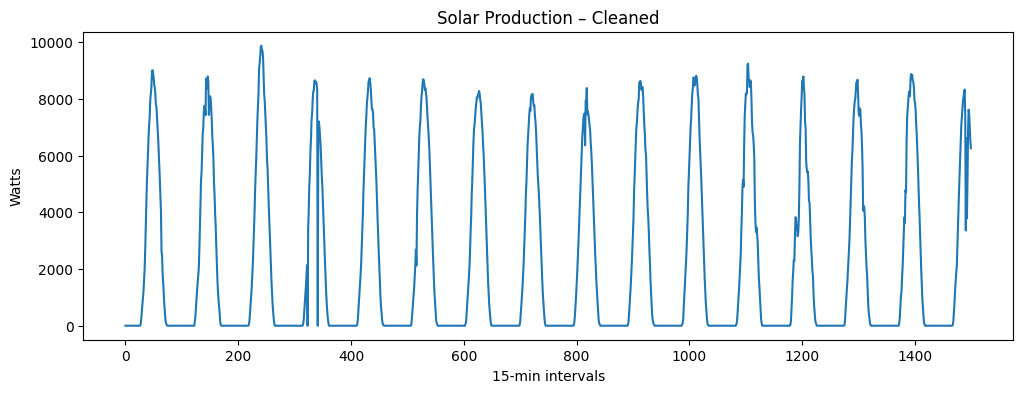

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df["solar_production"][:1500])
plt.title("Solar Production – Cleaned")
plt.xlabel("15-min intervals")
plt.ylabel("Watts")
plt.show()


STEP 13: Create lag features

In [53]:
df["solar_lag_1"] = df["solar_production"].shift(1)
df["solar_lag_2"] = df["solar_production"].shift(2)
df["solar_lag_96"] = df["solar_production"].shift(96)  # same time yesterday


Remove NaNs created by lagging

In [54]:
df.dropna(inplace=True)


STEP 14: Build FINAL solar dataset

In [55]:
solar_df = df[
    [
        "solar_production",
        "hour",
        "month",
        "weekday",
        "day_night",
        "solar_lag_1",
        "solar_lag_2",
        "solar_lag_96"
    ]
]


In [56]:
solar_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 18922 entries, 121 to 35025
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   solar_production  18922 non-null  float64
 1   hour              18922 non-null  int32  
 2   month             18922 non-null  int32  
 3   weekday           18922 non-null  int32  
 4   day_night         18922 non-null  int64  
 5   solar_lag_1       18922 non-null  float64
 6   solar_lag_2       18922 non-null  float64
 7   solar_lag_96      18922 non-null  float64
dtypes: float64(4), int32(3), int64(1)
memory usage: 1.1 MB


STEP 15: Save dataset

In [57]:
solar_df.to_csv("solar_preprocessed_dataset.csv", index=False)


STEP 16.1: Load dataset

In [58]:
import pandas as pd

solar_df = pd.read_csv("solar_preprocessed_dataset.csv")
solar_df.head()


,solar_production,hour,month,weekday,day_night,solar_lag_1,solar_lag_2,solar_lag_96
0,0.00000,6,1,0,1,0.00000,0.00000,0.00000
1,0.00000,6,1,0,1,0.00000,0.00000,0.00000
2,144.33333,6,1,0,1,0.00000,0.00000,57.00000
3,307.66666,7,1,0,1,144.33333,0.00000,236.33333
4,629.33330,7,1,0,1,307.66666,144.33333,468.66666


STEP 16.2: Define features (X) and target (y)

In [59]:
X = solar_df.drop("solar_production", axis=1)
y = solar_df["solar_production"]


STEP 16.3: Train–test split (TIME-AWARE)

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


STEP 16.4: Train baseline model (Linear Regression)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


In [62]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression
MAE: 586.500039315111
RMSE: 925.3893827371533
R2: 0.897795249815155


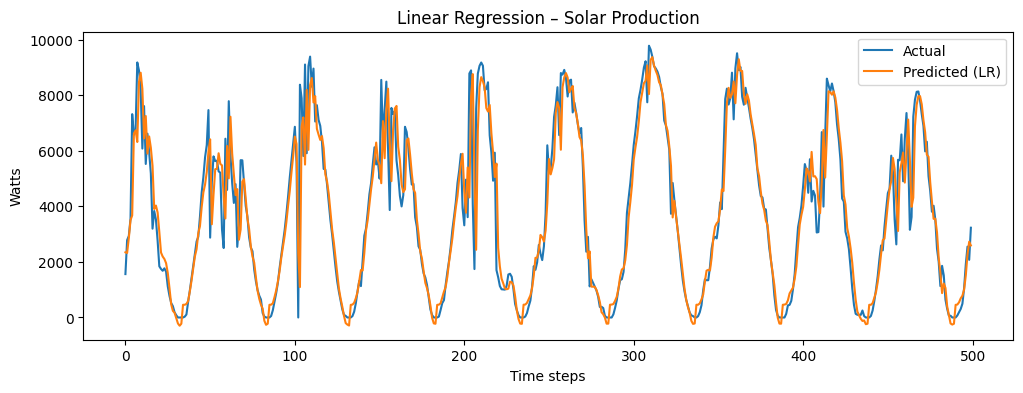

In [63]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred_lr[:500], label="Predicted (LR)")
plt.title("Linear Regression – Solar Production")
plt.xlabel("Time steps")
plt.ylabel("Watts")
plt.legend()
plt.show()


STEP 16.5: Random Forest

In [64]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest
MAE: 535.9774145508782
RMSE: 924.8825327776437
R2: 0.897907177373336


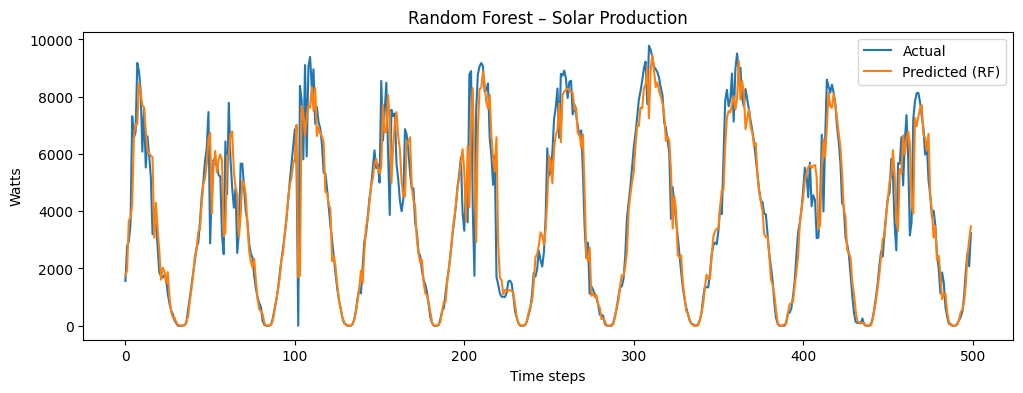

In [65]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred_rf[:500], label="Predicted (RF)")
plt.title("Random Forest – Solar Production")
plt.xlabel("Time steps")
plt.ylabel("Watts")
plt.legend()
plt.show()


STEP 16.6: Gradient Boosting

In [66]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting")
print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2:", r2_gbr)


Gradient Boosting
MAE: 515.8495172684443
RMSE: 888.3870363510424
R2: 0.9058052969540628


In [96]:
import joblib

joblib.dump(gbr, "solar_gradient_boosting_model.pkl")

print("Gradient Boosting solar model saved successfully!")


Gradient Boosting solar model saved successfully!


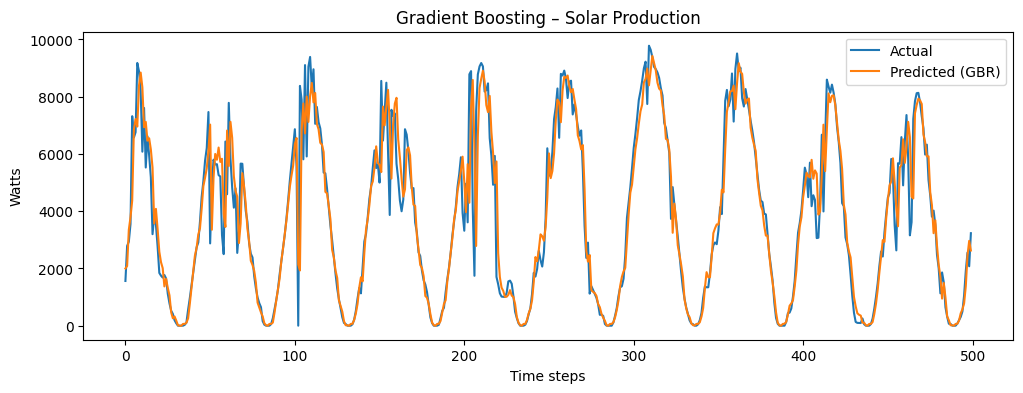

In [67]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred_gbr[:500], label="Predicted (GBR)")
plt.title("Gradient Boosting – Solar Production")
plt.xlabel("Time steps")
plt.ylabel("Watts")
plt.legend()
plt.show()


STEP 16.7: FINAL COMPARISON TABLE

In [68]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_lr, mae_rf, mae_gbr],
    "RMSE": [rmse_lr, rmse_rf, rmse_gbr],
    "R2 Score": [r2_lr, r2_rf, r2_gbr]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,586.500039,925.389383,0.897795
1,Random Forest,535.977415,924.882533,0.897907
2,Gradient Boosting,515.849517,888.387036,0.905805


STEP 17: Prepare data for GRU

STEP 17.1: Load dataset

In [69]:
import pandas as pd
import numpy as np

solar_df = pd.read_csv("solar_preprocessed_dataset.csv")


STEP 17.2: Separate features & target

In [70]:
X = solar_df.drop("solar_production", axis=1).values
y = solar_df["solar_production"].values


STEP 17.3: Scale the data

In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))


STEP 17.4: Create sequences (sliding window)

In [72]:
def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 24   # 6 hours (24 × 15 min)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, TIME_STEPS)


STEP 17.5: Train–test split (NO shuffle)

In [73]:
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]


STEP 18: Build GRU model

In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout


In [75]:
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 64)         │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,457 (91.63 KB)

 Trainable params: 23,457 (91.63 KB)

 Non-trainable params: 0 (0.00 B)

STEP 18.1: Train model

In [76]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 0.0195 - val_loss: 0.0168
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0114 - val_loss: 0.0137
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0107 - val_loss: 0.0144
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0098 - val_loss: 0.0131
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0097 - val_loss: 0.0130
Epoch 6/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0093 - val_loss: 0.0130
Epoch 7/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0092 - val_loss: 0.0133
Epoch 8/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0095 - val_loss: 0.0129
Epoch 9/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0090 - val_loss: 0.0129
Epoch 10/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0091 - val_loss: 0.0130
Epoch 11/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0089 - val_loss: 0.0131
Epoch 12/20
426/426 ━━━━━━━━━━

STEP 19: Evaluate GRU model

STEP 19.1: Make predictions

In [77]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)


119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


STEP 19.2: Calculate metrics (MAE, RMSE, R²)

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_gru = mean_absolute_error(y_test_actual, y_pred)
rmse_gru = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2_gru = r2_score(y_test_actual, y_pred)

print("GRU Solar Model")
print("MAE:", mae_gru)
print("RMSE:", rmse_gru)
print("R2:", r2_gru)


GRU Solar Model
MAE: 746.5026527578959
RMSE: 1127.295283936193
R2: 0.8484398748802874


STEP 19.3: Actual vs Predicted graph (GRU)

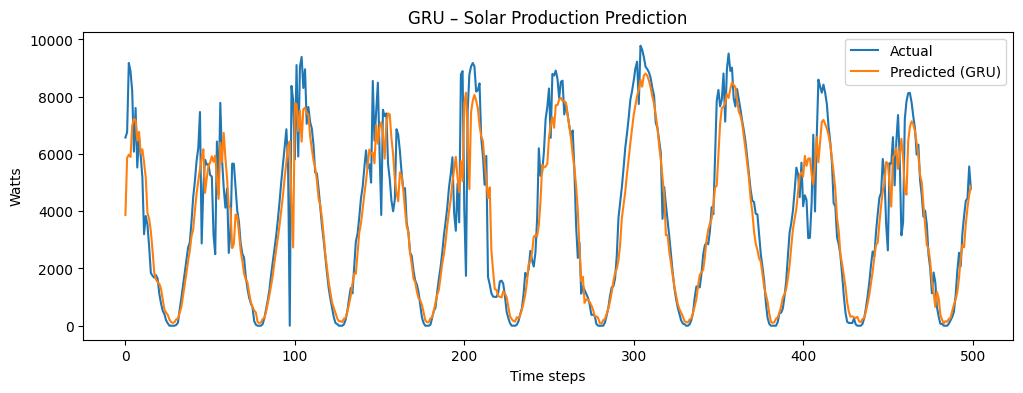

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test_actual[:500], label="Actual")
plt.plot(y_pred[:500], label="Predicted (GRU)")
plt.title("GRU – Solar Production Prediction")
plt.xlabel("Time steps")
plt.ylabel("Watts")
plt.legend()
plt.show()


STEP 20: Save trained GRU model

In [80]:
model.save("solar_gru_model.h5")


Also save scalers

In [81]:
import joblib

joblib.dump(scaler_X, "solar_scaler_X.pkl")
joblib.dump(scaler_y, "solar_scaler_y.pkl")


['solar_scaler_y.pkl']

STEP 21: Build LSTM model

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [83]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

STEP 21.1: Train LSTM model

In [84]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - loss: 0.0279 - val_loss: 0.0168
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0115 - val_loss: 0.0164
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0111 - val_loss: 0.0157
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0108 - val_loss: 0.0160
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0097 - val_loss: 0.0143
Epoch 6/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0095 - val_loss: 0.0138
Epoch 7/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0093 - val_loss: 0.0143
Epoch 8/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0090 - val_loss: 0.0133
Epoch 9/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0094 - val_loss: 0.0131
Epoch 10/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.0089 - val_loss: 0.0131
Epoch 11/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 0.0090 - val_loss: 0.0134
Epoch 12/20
426/426 ━━━━━━━━━━━

STEP 22: Evaluate LSTM model

STEP 22.1: Predictions

In [85]:
y_pred_lstm_scaled = lstm_model.predict(X_test)

y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)


119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


STEP 22.2: Metrics (MAE, RMSE, R²)

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
r2_lstm = r2_score(y_test_actual, y_pred_lstm)

print("LSTM Solar Model")
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("R2:", r2_lstm)


LSTM Solar Model
MAE: 719.7723329967905
RMSE: 1137.8788364263614
R2: 0.8455806873958928


STEP 22.3: Actual vs Predicted graph (LSTM)

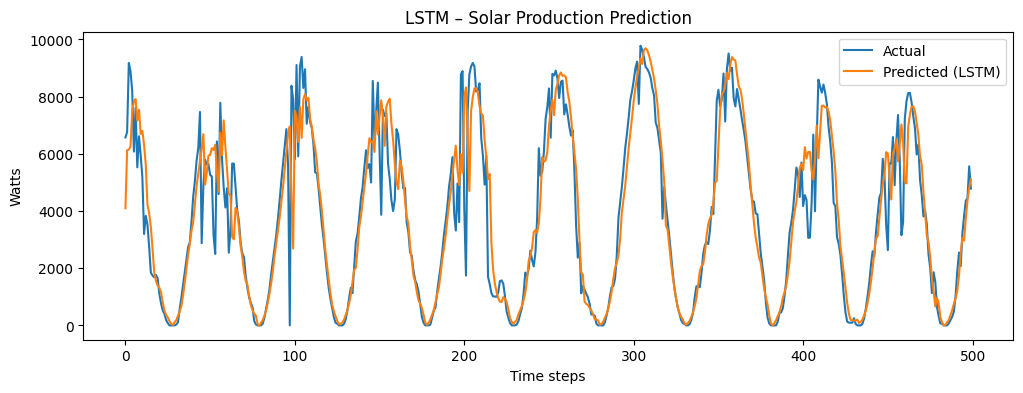

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test_actual[:500], label="Actual")
plt.plot(y_pred_lstm[:500], label="Predicted (LSTM)")
plt.title("LSTM – Solar Production Prediction")
plt.xlabel("Time steps")
plt.ylabel("Watts")
plt.legend()
plt.show()


STEP 23: Save LSTM model

In [88]:
lstm_model.save("solar_lstm_model.h5")


 Create FINAL comparison table

In [89]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "GRU",
        "LSTM"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_gbr,
        mae_gru,
        mae_lstm
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gbr,
        rmse_gru,
        rmse_lstm
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_gbr,
        r2_gru,
        r2_lstm
    ]
})

final_results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,586.500039,925.389383,0.897795
1,Random Forest,535.977415,924.882533,0.897907
2,Gradient Boosting,515.849517,888.387036,0.905805
3,GRU,746.502653,1127.295284,0.848440
4,LSTM,719.772333,1137.878836,0.845581


Save results

In [90]:
final_results.to_csv("solar_model_comparison.csv", index=False)


MAE comparison graph

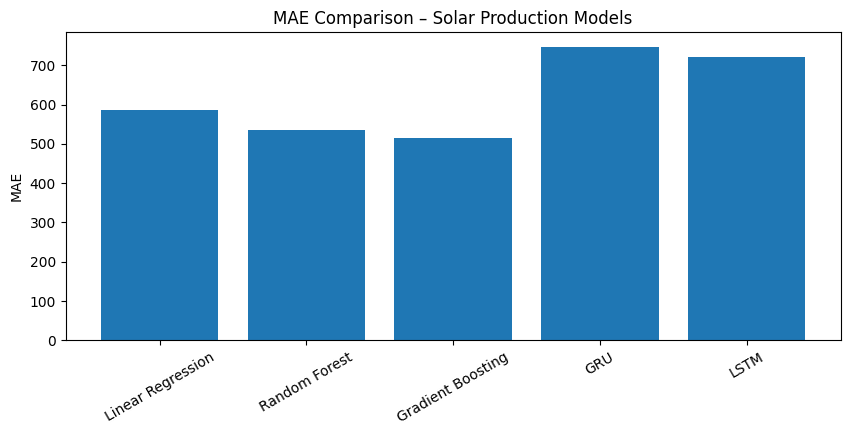

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(final_results["Model"], final_results["MAE"])
plt.title("MAE Comparison – Solar Production Models")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.show()


RMSE comparison graph

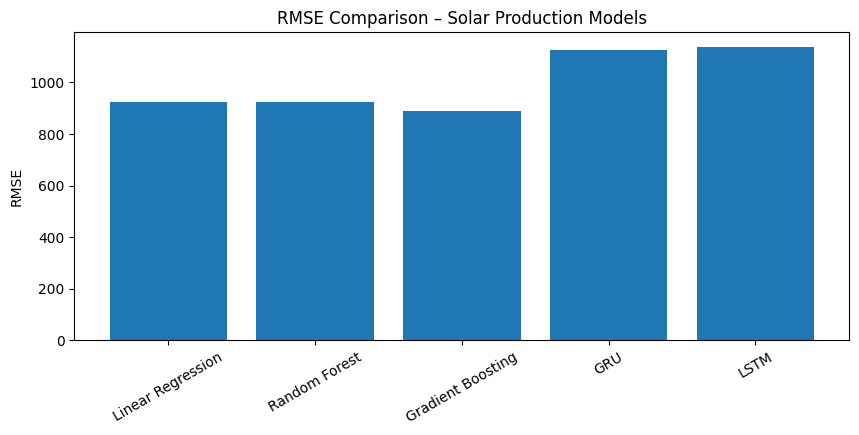

In [92]:
plt.figure(figsize=(10,4))
plt.bar(final_results["Model"], final_results["RMSE"])
plt.title("RMSE Comparison – Solar Production Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()


R² comparison graph

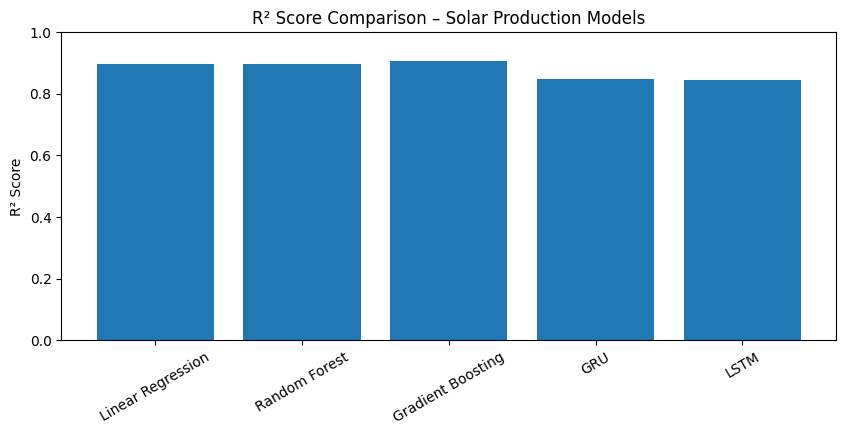

In [93]:
plt.figure(figsize=(10,4))
plt.bar(final_results["Model"], final_results["R2 Score"])
plt.title("R² Score Comparison – Solar Production Models")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()


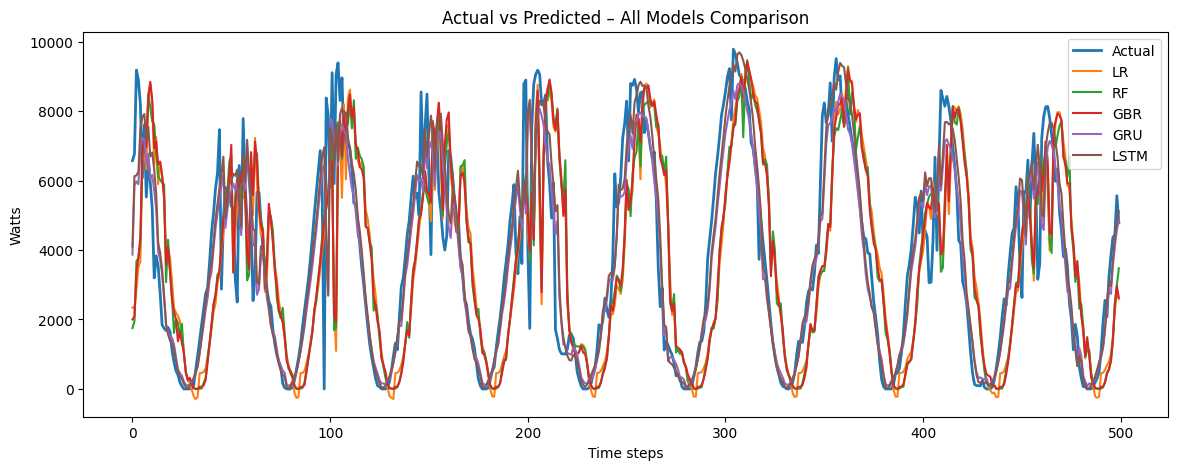

In [95]:
PLOT_LEN = 500
plt.figure(figsize=(14,5))

# Note: Base models and sequence models might have a small shift in their test sets
plt.plot(y_test_actual[:PLOT_LEN], label="Actual", linewidth=2)
plt.plot(y_pred_lr[:PLOT_LEN], label="LR")
plt.plot(y_pred_rf[:PLOT_LEN], label="RF")
plt.plot(y_pred_gbr[:PLOT_LEN], label="GBR")
plt.plot(y_pred[:PLOT_LEN], label="GRU")
plt.plot(y_pred_lstm[:PLOT_LEN], label="LSTM")

plt.title("Actual vs Predicted – All Models Comparison")
plt.xlabel("Time steps")
plt.ylabel("Watts")
plt.legend()
plt.show()